# 01 - Exploratory Data Analysis

Explore the LLM logs before building features: volumes by department, prompt/response length, session behavior, and time-of-day patterns. This also applies the `access` filter (default `nextjs`) that the rest of the pipeline will use.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import config
import utils

sns.set_theme(style="whitegrid")

df_all = utils.load_logs()
df = utils.filter_by_access(df_all, access=config.ACCESS_FILTER)

print(f"Loaded {len(df_all)} total rows; {len(df)} rows after filtering to access='{config.ACCESS_FILTER}'")
df.head()

Loaded 1723 total rows; 1388 rows after filtering to access='nextjs'


,timestamp,username,department,session_id,access,prompt,response,is_anomaly,anomaly_type
0,2026-06-07 12:26:44,fin_user07,Finance,S000409,nextjs,What is the variance on cost center 4021 versu...,cost center 4021 is tracking close to forecast...,0,normal
1,2026-06-07 12:32:44,fin_user07,Finance,S000409,nextjs,What approvals are needed to adjust the genera...,the general ledger is tracking close to foreca...,0,normal
2,2026-06-07 12:36:44,fin_user07,Finance,S000409,nextjs,What is the variance on the latest expense rep...,the latest expense report is tracking close to...,0,normal
3,2026-06-07 12:38:44,fin_user07,Finance,S000409,nextjs,Summarize the annual audit for this quarter.,the annual audit is tracking close to forecast...,0,normal
4,2026-06-07 16:07:44,cou_user08,Counterparties,S000522,nextjs,Summarize the ISDA agreement terms with Acme B...,Current exposure to Acme Bank is within the ap...,0,normal


## 1. Basic shape and quality checks

In [2]:
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nRows per department:")
print(df["department"].value_counts())
print("\nUnique users:", df["username"].nunique(), "| Unique sessions:", df["session_id"].nunique())

Date range: 2026-06-07 12:26:44 to 2026-09-05 20:38:54

Missing values per column:
timestamp       0
username        0
department      0
session_id      0
access          0
prompt          0
response        0
is_anomaly      0
anomaly_type    0
dtype: int64

Rows per department:
department
Counterparties        283
Trade                 255
Finance               249
Investment Banking    215
HR                    194
Technology            192
Name: count, dtype: int64

Unique users: 90 | Unique sessions: 470


## 2. Department-wise volume

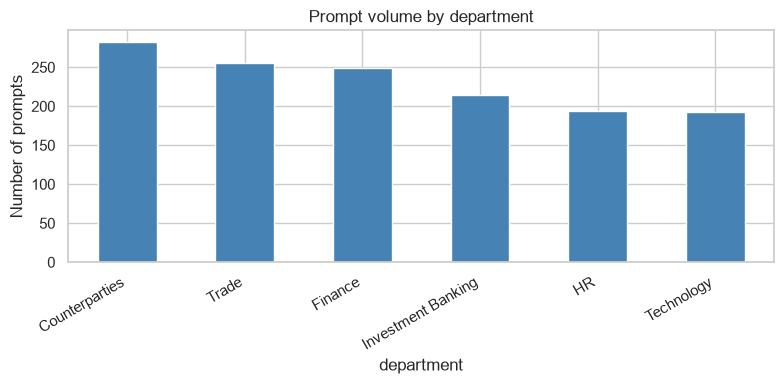

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
df["department"].value_counts().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Prompt volume by department")
ax.set_ylabel("Number of prompts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Prompt / response length distributions

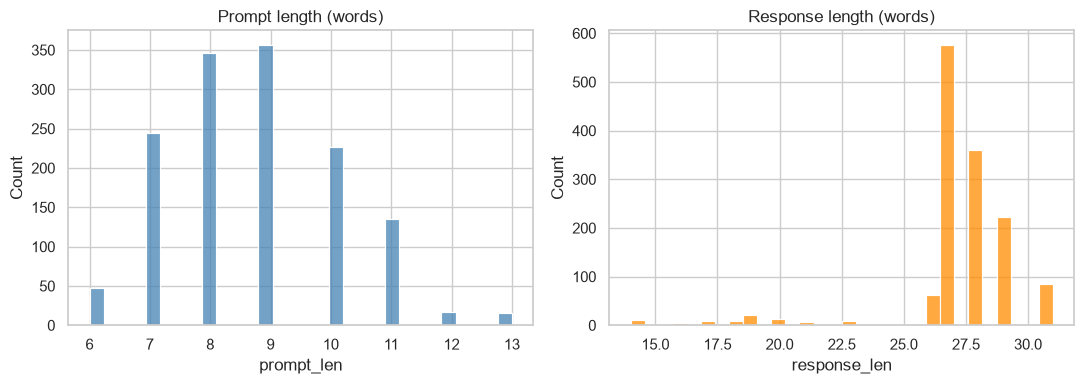

        prompt_len  response_len
count  1388.000000   1388.000000
mean      8.735591     27.290346
std       1.422844      2.514556
min       6.000000     14.000000
25%       8.000000     27.000000
50%       9.000000     27.000000
75%      10.000000     28.000000
max      13.000000     31.000000


In [4]:
df["prompt_len"] = df["prompt"].astype(str).str.split().str.len()
df["response_len"] = df["response"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["prompt_len"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Prompt length (words)")
sns.histplot(df["response_len"], bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Response length (words)")
plt.tight_layout()
plt.show()

print(df[["prompt_len", "response_len"]].describe())

## 4. Prompt length by department

Different departments may naturally write shorter/longer prompts - useful context before we decide whether length should be a feature.

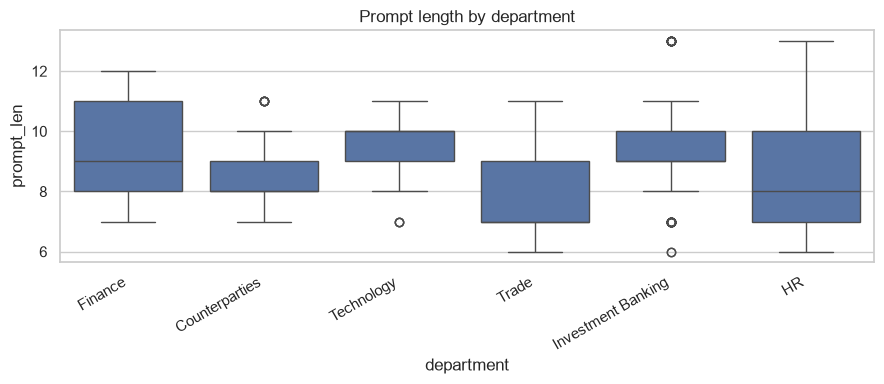

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="department", y="prompt_len", ax=ax)
ax.set_title("Prompt length by department")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Session-level behavior

Turns per session and session duration - these become behavioral features later, and also help sanity-check that our session grouping makes sense.

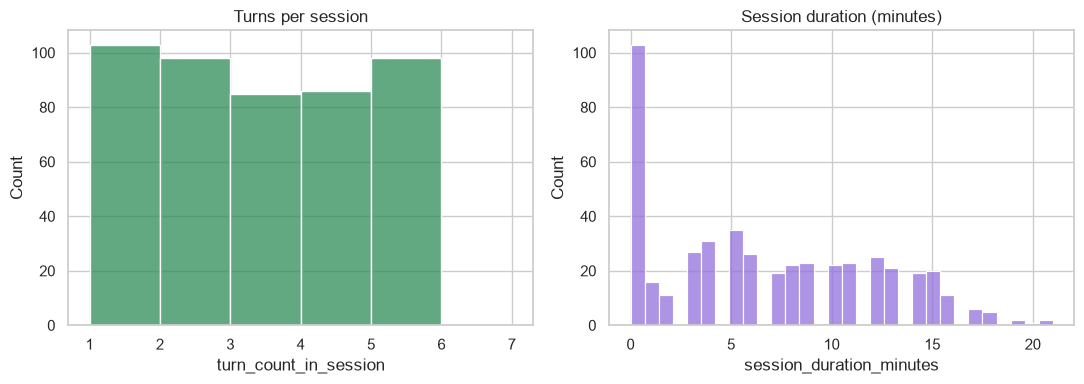

       turn_count_in_session  session_duration_minutes  avg_gap_seconds
count             470.000000                470.000000        470.00000
mean                2.953191                  6.744681        162.37234
std                 1.450660                  5.456039        106.39198
min                 1.000000                  0.000000          0.00000
25%                 2.000000                  1.000000         60.00000
50%                 3.000000                  6.000000        180.00000
75%                 4.000000                 11.000000        240.00000
max                 5.000000                 21.000000        360.00000


In [6]:
df_sessions = utils.build_session_aggregates(df)
session_summary = df_sessions.drop_duplicates("session_id")[
    ["session_id", "department", "turn_count_in_session", "session_duration_minutes", "avg_gap_seconds"]
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(session_summary["turn_count_in_session"], bins=range(1, 8), ax=axes[0], color="seagreen")
axes[0].set_title("Turns per session")
sns.histplot(session_summary["session_duration_minutes"], bins=30, ax=axes[1], color="mediumpurple")
axes[1].set_title("Session duration (minutes)")
plt.tight_layout()
plt.show()

print(session_summary.describe())

## 6. Volume by hour of day and weekday

Sanity-check for "off-hours" behavior - most business usage should cluster in working hours/weekdays.

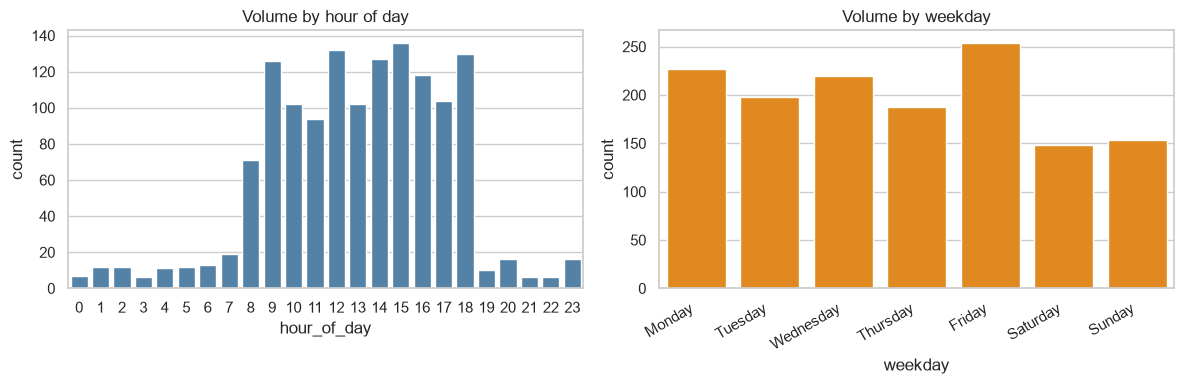

In [7]:
df["hour_of_day"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=df["hour_of_day"], ax=axes[0], color="steelblue")
axes[0].set_title("Volume by hour of day")
sns.countplot(x=df["weekday"], order=weekday_order, ax=axes[1], color="darkorange")
axes[1].set_title("Volume by weekday")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Top terms per department (quick topic sanity check)

A cheap check that departments are actually topically distinct before we invest in embeddings - top TF-IDF terms per department, on cleaned text.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["clean_text"] = (df["prompt"].astype(str) + " " + df["response"].astype(str)).apply(
    utils.clean_text_remove_stopwords
)

# Use whatever departments actually appear in the data, not a hardcoded list -
# so this works unchanged no matter what your real department names are.
for dept in df["department"].dropna().unique():
    dept_text = df.loc[df["department"] == dept, "clean_text"]
    vectorizer = TfidfVectorizer(max_features=10)
    tfidf = vectorizer.fit_transform(dept_text)
    scores = tfidf.sum(axis=0).A1
    top_terms = sorted(zip(vectorizer.get_feature_names_out(), scores), key=lambda x: -x[1])
    print(f"{dept}: {', '.join(t for t, _ in top_terms)}")

## 8. Synthetic-data-only check: where are the injected anomalies?

This uses `is_anomaly`/`anomaly_type`, which only exist because this is synthetic data with a known answer key. **Real logs won't have these columns** - this cell is just to confirm our synthetic data is set up sensibly before we build features and models on it.

anomaly_type
normal           1278
off_topic          68
dept_mismatch      30
security           12
Name: count, dtype: int64

Overall anomaly rate: 7.9%


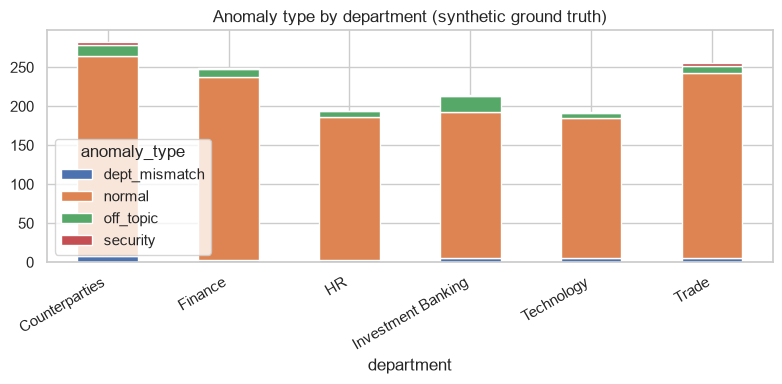

In [9]:
print(df["anomaly_type"].value_counts())
print(f"\nOverall anomaly rate: {df['is_anomaly'].mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
pd.crosstab(df["department"], df["anomaly_type"]).plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Anomaly type by department (synthetic ground truth)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()